### We begin with EDA and feature engineering here

In [24]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels
import numpy as np


In [25]:
#importing dataset
df = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Yield-Curve-Forecasting-Using-Macroeconomic-Indicators\Data\Processed\master_dataset_outer.csv")

we do the following before splitting the data
* Shape
* Missing values
* Summary statistics
* Time series plots
* Histograms
* Correlation heatmap



In [26]:
df.shape

(414, 18)

In [27]:
df.head(10)

,observation_date,DGS3MO,DGS1,DGS2,DGS5,DGS10,DGS30,CPIAUCSL,CPILFESL,FEDFUNDS,UNRATE,GDPC1,INDPRO,RSAFS,HOUST,UMCSENT,VIXCLS,DCOILWTICO
0,1992-01,3.94,4.23,5.11,6.44,7.31,7.77,138.3,145.1,4.03,7.3,10236.435,61.4616,159177.0,1176.0,67.5,17.683182,18.785455
1,1992-02,4.03,4.35,5.27,6.58,7.27,7.80,138.6,145.4,4.06,7.4,10236.435,61.8955,159189.0,1250.0,68.8,17.477368,19.012500
2,1992-03,4.15,4.54,5.60,6.94,7.54,7.96,139.1,145.9,3.98,7.4,10236.435,62.4232,158647.0,1297.0,76.0,17.520455,18.921818
3,1992-04,3.79,4.40,5.46,6.91,7.61,8.06,139.4,146.3,3.73,7.4,10347.429,62.8970,159921.0,1099.0,77.2,16.562857,20.230000
4,1992-05,3.79,4.24,5.19,6.61,7.33,7.84,139.7,146.8,3.82,7.6,10347.429,63.1040,160471.0,1214.0,79.2,15.077000,20.975500
5,1992-06,3.65,4.05,4.83,6.29,7.14,7.79,140.1,147.1,3.76,7.8,10347.429,63.1363,161205.0,1145.0,80.4,15.203182,22.384545
6,1992-07,3.25,3.62,4.42,5.84,6.72,7.46,140.5,147.6,3.25,7.7,10449.673,63.7176,162855.0,1139.0,76.6,13.601818,21.775217
7,1992-08,3.23,3.47,4.15,5.60,6.62,7.42,140.8,147.9,3.30,7.6,10449.673,63.3613,162412.0,1226.0,76.1,14.421905,21.339048
8,1992-09,2.75,3.06,3.80,5.33,6.37,7.38,141.1,148.1,3.22,7.6,10449.673,63.5703,164361.0,1186.0,75.6,13.696667,21.881364
9,1992-10,3.03,3.54,4.40,5.90,6.80,7.63,141.7,148.8,3.10,7.3,10558.648,63.9995,166063.0,1244.0,73.3,17.636818,21.685909


In [28]:
df.describe([0.10,0.25,0.50,0.75,0.90,0.99])

,DGS3MO,DGS1,DGS2,DGS5,DGS10,DGS30,CPIAUCSL,CPILFESL,FEDFUNDS,UNRATE,GDPC1,INDPRO,RSAFS,HOUST,UMCSENT,VIXCLS,DCOILWTICO
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,413.00000,413.000000,414.000000,413.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2.580580,2.788551,3.002754,3.510072,4.005700,4.541208,216.19637,222.217429,2.657536,5.624939,16854.871630,92.143399,387019.289855,1339.202899,84.258937,19.385478,53.617631
std,2.111698,2.107173,2.079959,1.899101,1.725647,1.590011,51.00689,49.600387,2.157424,1.773615,3819.955256,11.177624,159265.544713,380.007719,14.570086,7.506896,29.025763
min,0.000000,0.050000,0.110000,0.210000,0.550000,1.200000,138.30000,145.100000,0.050000,3.400000,10236.435000,61.461600,158647.000000,478.000000,44.800000,10.125455,11.347273
10%,0.050000,0.150000,0.316000,1.033000,1.780000,2.580000,152.44000,161.160000,0.090000,3.820000,11382.697700,71.608930,199491.900000,728.100000,62.860000,12.327324,18.402208
25%,0.195000,0.502500,0.877500,1.760000,2.522500,3.100000,172.70000,181.900000,0.200000,4.300000,14145.312000,88.508300,268416.500000,1146.000000,73.600000,13.986153,25.817174
50%,2.360000,2.610000,2.970000,3.615000,4.030000,4.585000,215.44500,218.253000,2.395000,5.200000,16776.374500,96.516650,357553.500000,1375.500000,87.300000,17.619710,52.741524
75%,4.730000,4.815000,4.710000,4.935000,5.280000,5.660000,246.62600,253.526000,4.830000,6.400000,19660.766000,100.557625,473874.000000,1579.750000,95.100000,22.836407,75.777730
90%,5.344000,5.517000,5.821000,6.174000,6.411000,6.800000,298.82280,301.180200,5.490000,8.280000,22391.228400,101.882880,667903.600000,1786.200000,101.400000,28.104379,94.726030
99%,6.182700,6.430900,6.798700,7.254000,7.608700,7.883500,327.35536,333.425720,6.508700,9.988000,24180.419000,103.950110,740425.200000,2140.750000,109.135000,45.469767,114.543773


In [29]:
target = ["DGS3MO","DGS1","DGS2","DGS5","DGS10","DGS30"]

In [30]:
#converting to datetime format
df["observation_date"] = pd.to_datetime(df["observation_date"], format='%Y-%m')

In [31]:
df.dtypes

observation_date    datetime64[us]
DGS3MO                     float64
DGS1                       float64
DGS2                       float64
DGS5                       float64
DGS10                      float64
DGS30                      float64
CPIAUCSL                   float64
CPILFESL                   float64
FEDFUNDS                   float64
UNRATE                     float64
GDPC1                      float64
INDPRO                     float64
RSAFS                      float64
HOUST                      float64
UMCSENT                    float64
VIXCLS                     float64
DCOILWTICO                 float64
dtype: object

In [32]:
#checking missing values
df.isna().sum()

observation_date    0
DGS3MO              0
DGS1                0
DGS2                0
DGS5                0
DGS10               0
DGS30               0
CPIAUCSL            1
CPILFESL            1
FEDFUNDS            0
UNRATE              1
GDPC1               0
INDPRO              0
RSAFS               0
HOUST               0
UMCSENT             0
VIXCLS              0
DCOILWTICO          0
dtype: int64

array([[<Axes: title={'center': 'observation_date'}>,
        <Axes: title={'center': 'DGS3MO'}>,
        <Axes: title={'center': 'DGS1'}>,
        <Axes: title={'center': 'DGS2'}>],
       [<Axes: title={'center': 'DGS5'}>,
        <Axes: title={'center': 'DGS10'}>,
        <Axes: title={'center': 'DGS30'}>,
        <Axes: title={'center': 'CPIAUCSL'}>],
       [<Axes: title={'center': 'CPILFESL'}>,
        <Axes: title={'center': 'FEDFUNDS'}>,
        <Axes: title={'center': 'UNRATE'}>,
        <Axes: title={'center': 'GDPC1'}>],
       [<Axes: title={'center': 'INDPRO'}>,
        <Axes: title={'center': 'RSAFS'}>,
        <Axes: title={'center': 'HOUST'}>,
        <Axes: title={'center': 'UMCSENT'}>],
       [<Axes: title={'center': 'VIXCLS'}>,
        <Axes: title={'center': 'DCOILWTICO'}>, <Axes: >, <Axes: >]],
      dtype=object)

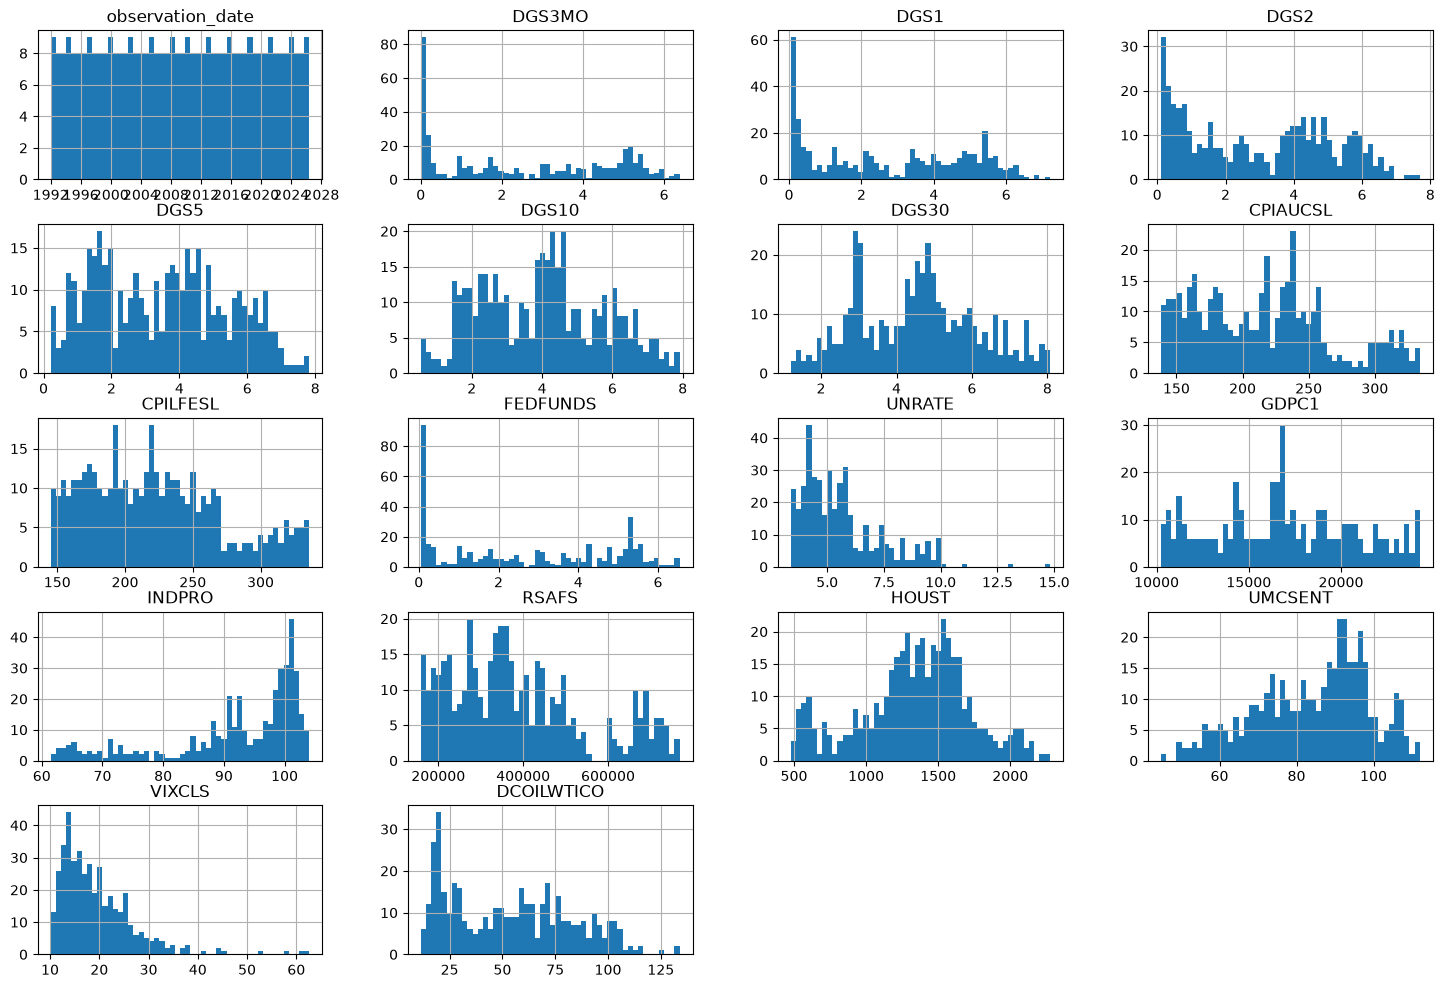

In [33]:
df.hist(figsize=(18,12), bins=50)

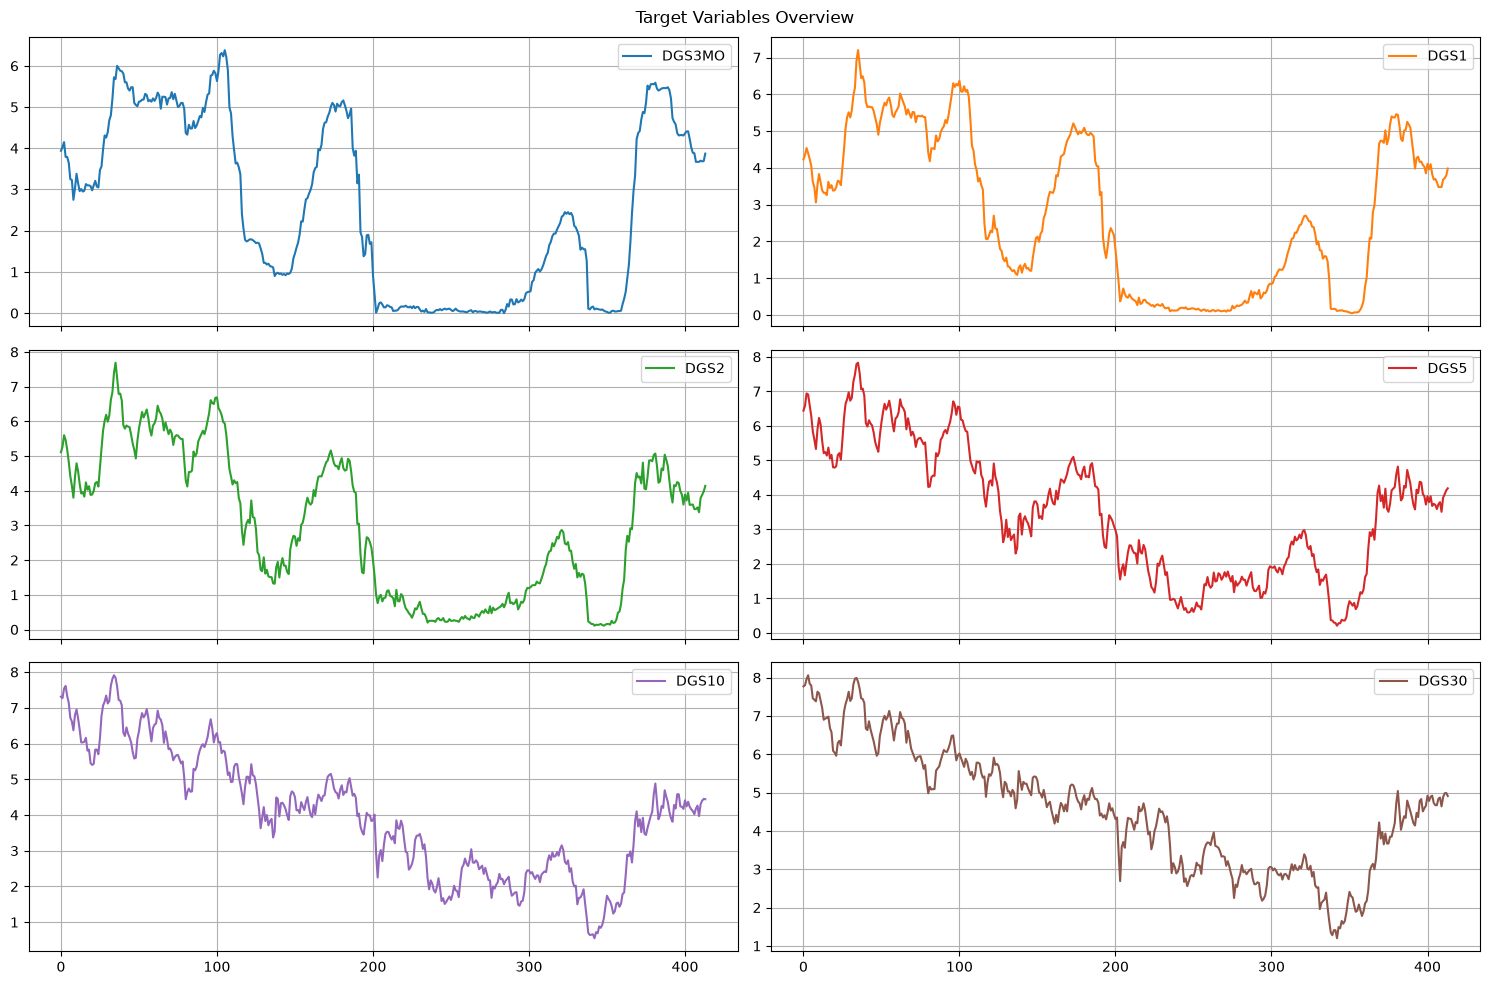

In [34]:
# Plots all target columns in a 2-column grid automatically
df[target].plot(
    subplots=True,
    layout=(-1, 2),  # -1 automatically calculates the required number of rows
    figsize=(15, 10),
    title="Target Variables Overview",
    grid=True,
)

plt.tight_layout()
plt.show()


In [35]:
#dealing with outliers
w1 = np.where(df["UNRATE"].isna())
w1

(array([405]),)

In [36]:
w2 = np.where(df["CPIAUCSL"].isna())
w2

(array([405]),)

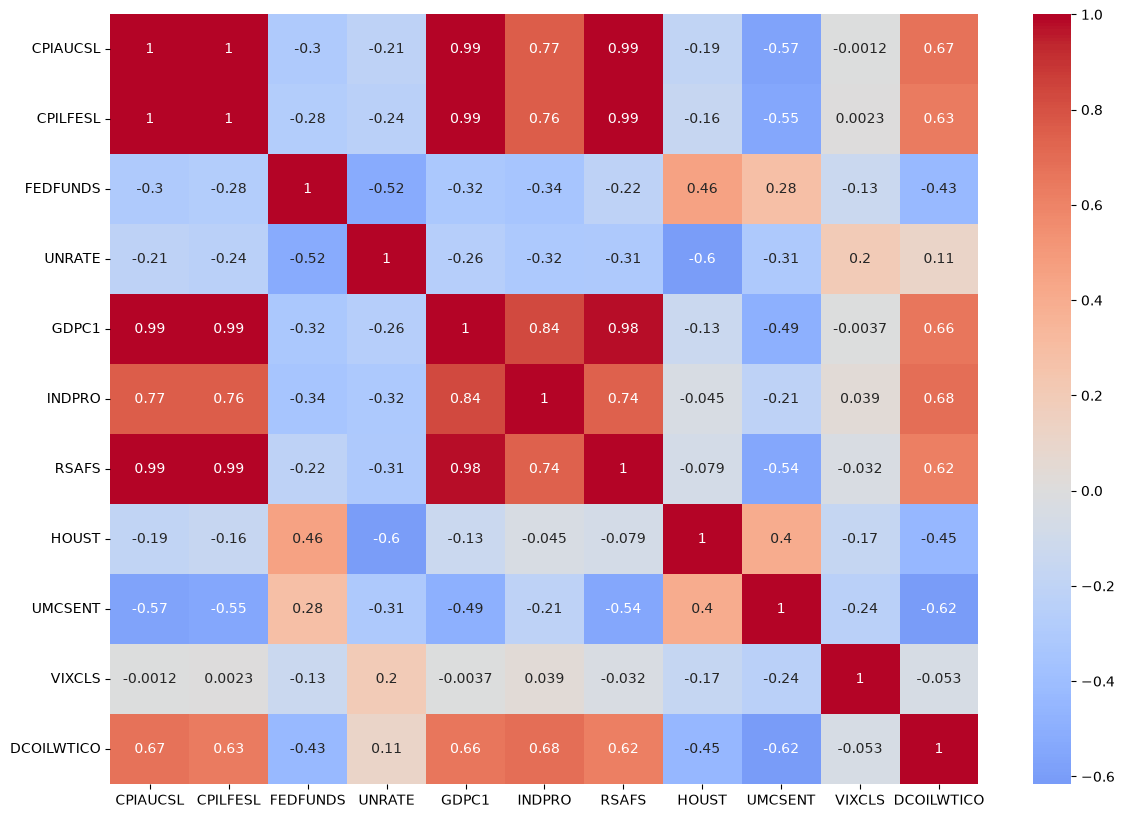

In [37]:
corre = df.drop(columns=[*target, "observation_date"]).corr()
plt.figure(figsize=(14,10))
sns.heatmap(corre,
            cmap="coolwarm",
            center=0,
            annot=True)
plt.show()

few features have high correlation due to which problem of multicolinearity may arise so we need to deal with them 

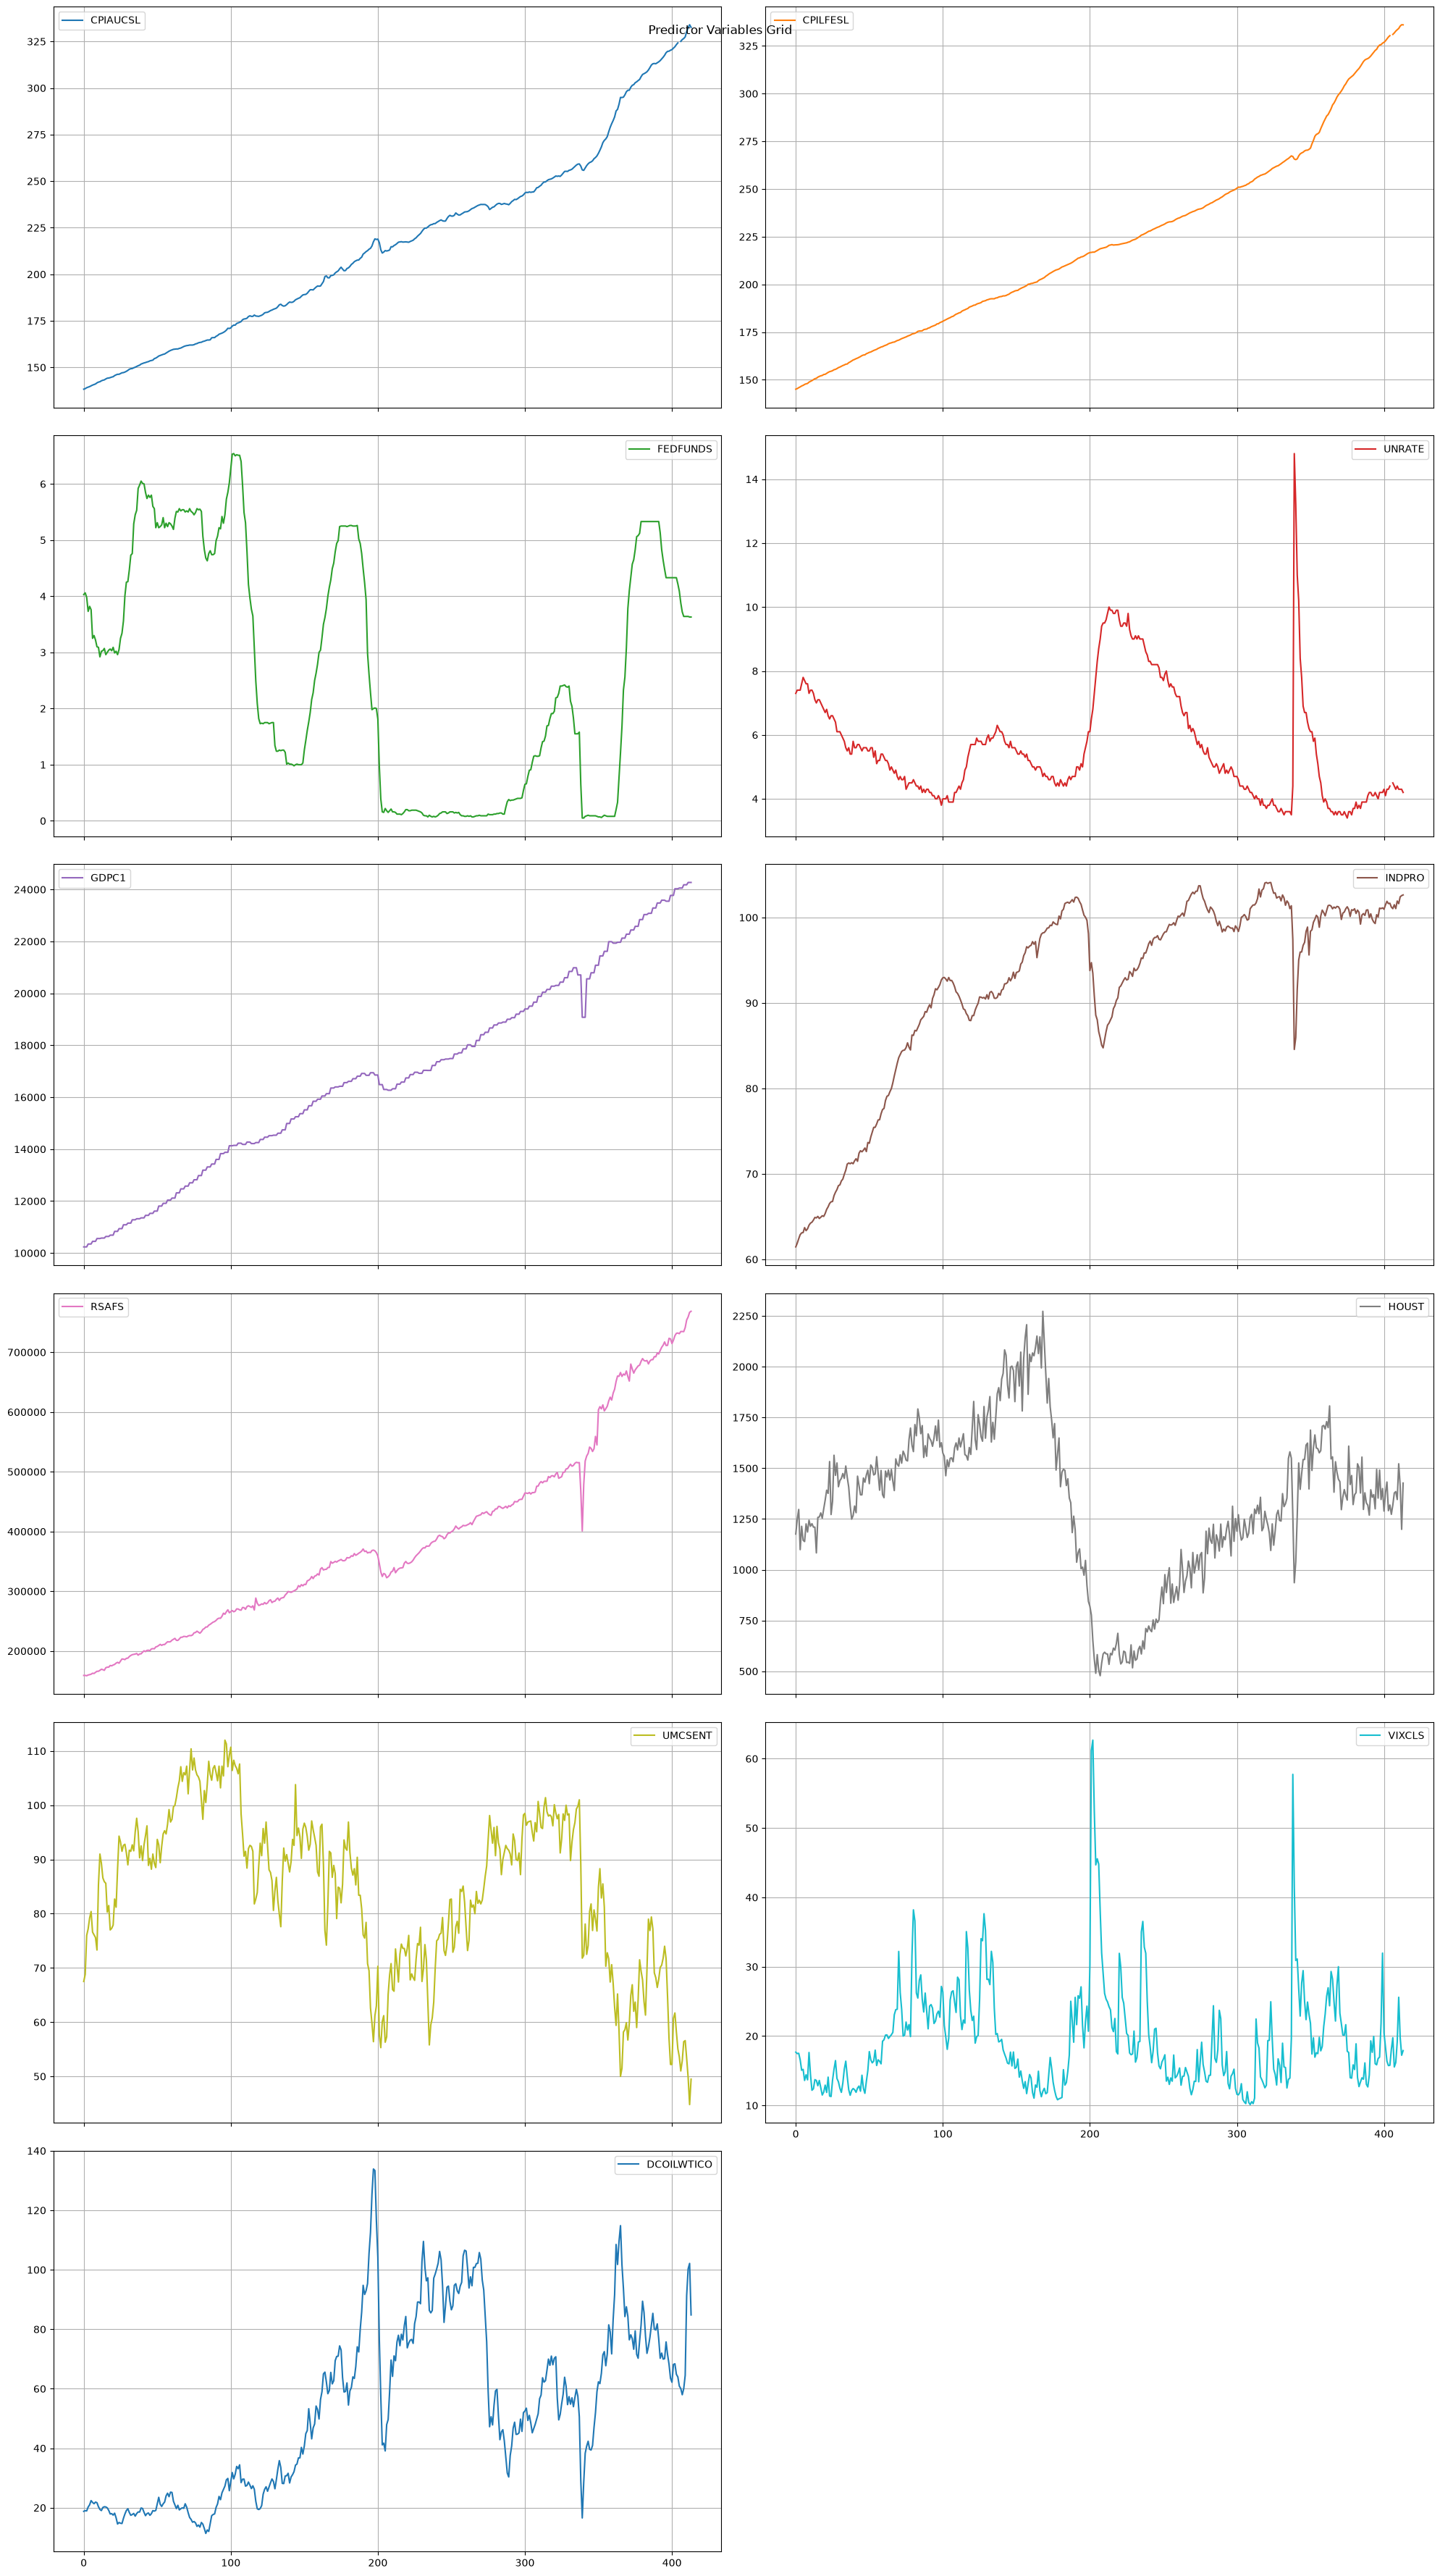

In [38]:
predictors = df.drop(columns=[*target, "observation_date"]).columns

df[predictors].plot(
    subplots=True,
    layout=(-1, 2), 
    figsize=(20, 6 * ((len(predictors) + 1) // 2)),  
    title="Predictor Variables Grid",
    grid=True,
)

plt.tight_layout()
plt.show()

data was already seasonally decomposed so we need not worry about seasonality

In [39]:
#405 is missing for we impute it with avg value of 404 and 406

## Feature Engineering

In [40]:
#splitting the dataset

train = df[df["observation_date"] < "2023-01"].copy()

test = df[df["observation_date"] >= "2023-01"].copy()


In [41]:
predictors = train.drop(columns = target).copy()
for c in predictors.columns:
    predictors[c,"lag1"] = predictors[c].shift(1)
    # Lag 1: Shift by 1 row (1 month)

    # Lag 3: Shift by 3 rows
    predictors[c,"lag3"] = predictors[c].shift(3)

    # Lag 6: Shift by 6 rows
    predictors[c,"lag6"] = predictors[c].shift(6)

    # Lag 12: Shift by 12 rows (Year-over-year temporal context)
    predictors[c,"lag12"] = predictors[c].shift(12)





In [42]:
predictors.head(13)

,observation_date,CPIAUCSL,CPILFESL,FEDFUNDS,UNRATE,GDPC1,INDPRO,RSAFS,HOUST,UMCSENT,...,"(UMCSENT, lag6)","(UMCSENT, lag12)","(VIXCLS, lag1)","(VIXCLS, lag3)","(VIXCLS, lag6)","(VIXCLS, lag12)","(DCOILWTICO, lag1)","(DCOILWTICO, lag3)","(DCOILWTICO, lag6)","(DCOILWTICO, lag12)"
0,1992-01-01,138.3,145.1,4.03,7.3,10236.435,61.4616,159177.0,1176.0,67.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1992-02-01,138.6,145.4,4.06,7.4,10236.435,61.8955,159189.0,1250.0,68.8,...,NaN,NaN,17.683182,NaN,NaN,NaN,18.785455,NaN,NaN,NaN
2,1992-03-01,139.1,145.9,3.98,7.4,10236.435,62.4232,158647.0,1297.0,76.0,...,NaN,NaN,17.477368,NaN,NaN,NaN,19.012500,NaN,NaN,NaN
3,1992-04-01,139.4,146.3,3.73,7.4,10347.429,62.8970,159921.0,1099.0,77.2,...,NaN,NaN,17.520455,17.683182,NaN,NaN,18.921818,18.785455,NaN,NaN
4,1992-05-01,139.7,146.8,3.82,7.6,10347.429,63.1040,160471.0,1214.0,79.2,...,NaN,NaN,16.562857,17.477368,NaN,NaN,20.230000,19.012500,NaN,NaN
5,1992-06-01,140.1,147.1,3.76,7.8,10347.429,63.1363,161205.0,1145.0,80.4,...,NaN,NaN,15.077000,17.520455,NaN,NaN,20.975500,18.921818,NaN,NaN
6,1992-07-01,140.5,147.6,3.25,7.7,10449.673,63.7176,162855.0,1139.0,76.6,...,67.5,NaN,15.203182,16.562857,17.683182,NaN,22.384545,20.230000,18.785455,NaN
7,1992-08-01,140.8,147.9,3.30,7.6,10449.673,63.3613,162412.0,1226.0,76.1,...,68.8,NaN,13.601818,15.077000,17.477368,NaN,21.775217,20.975500,19.012500,NaN
8,1992-09-01,141.1,148.1,3.22,7.6,10449.673,63.5703,164361.0,1186.0,75.6,...,76.0,NaN,14.421905,15.203182,17.520455,NaN,21.339048,22.384545,18.921818,NaN
9,1992-10-01,141.7,148.8,3.10,7.3,10558.648,63.9995,166063.0,1244.0,73.3,...,77.2,NaN,13.696667,13.601818,16.562857,NaN,21.881364,21.775217,20.230000,NaN


In [43]:
predictors.shape

(372, 60)

In [44]:
df = df.iloc[405].ffill()

In [45]:
#checking stationarity and differencing if needed
from statsmodels.tsa.stattools import adfuller
lol = train

for c in lol.columns:
    if c == "observation_date":
        continue
    result = adfuller(lol[c].dropna())
    print(f"ADF Statistic for {c:15}: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("differencing not needed")
    else:
        print("differencing needed")    

ADF Statistic for DGS3MO         : -2.6264, p-value: 0.0877
differencing needed
ADF Statistic for DGS1           : -2.5744, p-value: 0.0984
differencing needed
ADF Statistic for DGS2           : -1.6517, p-value: 0.4562
differencing needed
ADF Statistic for DGS5           : -2.0780, p-value: 0.2535
differencing needed
ADF Statistic for DGS10          : -2.2140, p-value: 0.2012
differencing needed
ADF Statistic for DGS30          : -2.2366, p-value: 0.1932
differencing needed


ADF Statistic for CPIAUCSL       : 1.5170, p-value: 0.9976
differencing needed
ADF Statistic for CPILFESL       : 2.0994, p-value: 0.9988
differencing needed
ADF Statistic for FEDFUNDS       : -2.6052, p-value: 0.0919
differencing needed
ADF Statistic for UNRATE         : -3.1749, p-value: 0.0215
differencing not needed
ADF Statistic for GDPC1          : -0.1964, p-value: 0.9389
differencing needed
ADF Statistic for INDPRO         : -2.6202, p-value: 0.0889
differencing needed
ADF Statistic for RSAFS          : 1.3450, p-value: 0.9968
differencing needed
ADF Statistic for HOUST          : -1.8138, p-value: 0.3736
differencing needed
ADF Statistic for UMCSENT        : -1.4072, p-value: 0.5788
differencing needed
ADF Statistic for VIXCLS         : -4.6738, p-value: 0.0001
differencing not needed
ADF Statistic for DCOILWTICO     : -2.4675, p-value: 0.1236
differencing needed


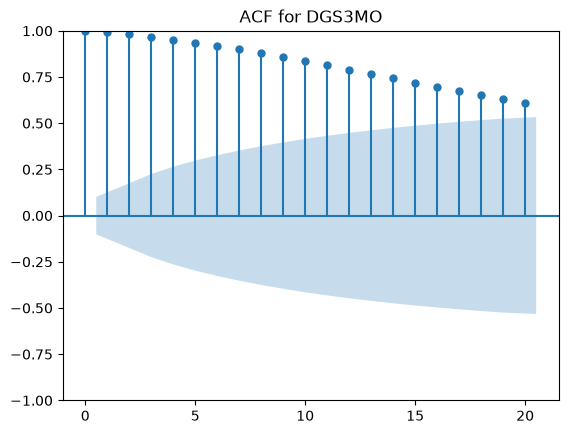

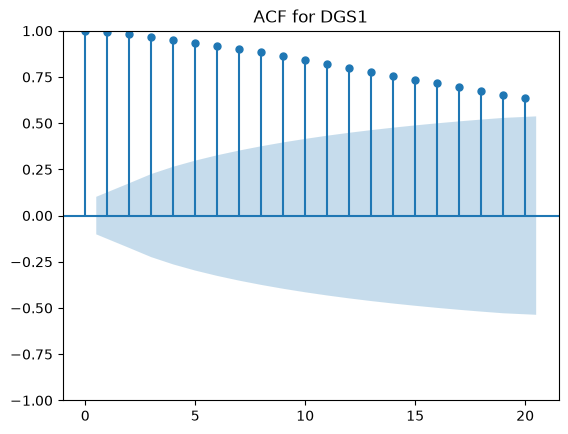

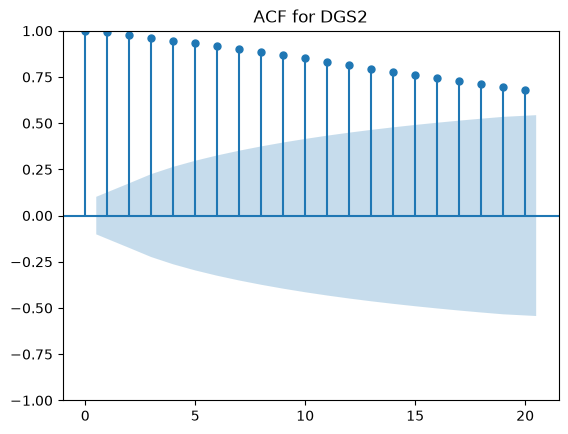

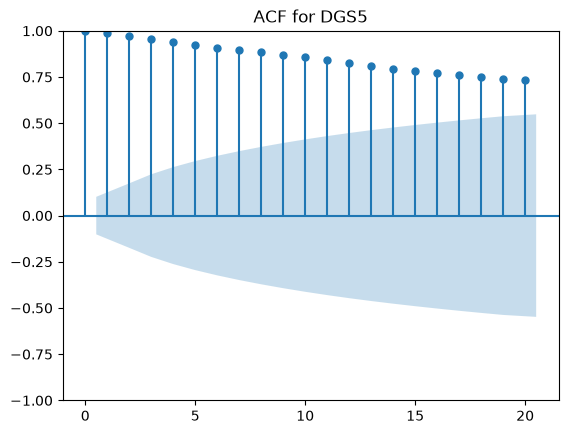

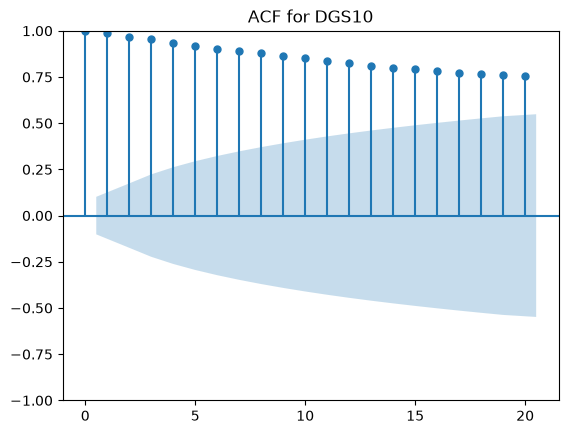

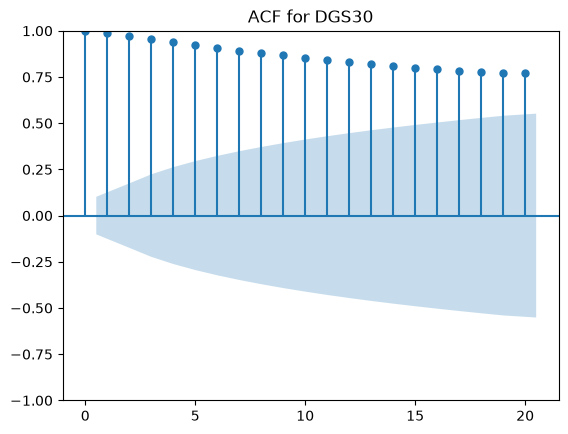

In [46]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
for c in target:
    plot_acf(train[c].dropna(), lags=20)
    plt.title(f"ACF for {c}")
    plt.show()



In [ ]:
#creating rolling window
import pandas as pd

# List of key predictor variables
key_vars = ["DGS10", "CPI", "FEDFUNDS", "Oil", "VIX"]

# Windows to compute (3-month, 6-month, 12-month)
windows = [3, 6, 12]

# Ensure your dataset is sorted chronologically by date
df = df.sort_index()

# Loop through each variable and window size to create features
for col in key_vars:
    for w in windows:
        # Shift by 1 first to prevent data leakage!
        # Mapping logical names to actual column names in the dataset
        col_mapping = {"CPI": "CPIAUCSL", "Oil": "DCOILWTICO", "VIX": "VIXCLS"}
        actual_col = col_mapping.get(col, col)
        shifted_series = train[actual_col].shift(1)

        # 1. Rolling Mean
        train[f"{col}_roll_mean_{w}m"] = shifted_series.rolling(window=w).mean()

        # 2. Rolling Standard Deviation (Volatility)
        train[f"{col}_roll_std_{w}m"] = shifted_series.rolling(window=w).std()

        # 3. Rolling Min
        train[f"{col}_roll_min_{w}m"] = shifted_series.rolling(window=w).min()

        # 4. Rolling Max
        train[f"{col}_roll_max_{w}m"] = shifted_series.rolling(window=w).max()

KeyError: 'CPI'